In [66]:
import os
from dotenv import load_dotenv
load_dotenv()
from langgraph.graph import START,END,StateGraph
from typing import  TypedDict,Annotated
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
import operator 
import json

##    start - parallel(DOE,COT,LANGUAGE)-> Final_res-feed and score - end

In [62]:
llm=ChatGroq(model='qwen/qwen3-32b',api_key=os.getenv('Groq_API_KEY'))   

In [63]:
class evalueation_schema(BaseModel):
    feedback: str = Field(description="Feedback on the essay")
    score: float = Field(description="Final score of the essay",ge=0,le=10)

structured_output = llm.with_structured_output(evalueation_schema)

In [64]:
prompt=f"""  Provide a final score out of 10 based and feedback on the following essay: {essay}"""
structured_output.invoke(prompt)

evalueation_schema(feedback='The essay provides a clear and structured overview of artificial intelligence, covering its applications and ethical implications. Strengths include a logical flow, relevant examples (e.g., healthcare, education), and a balanced discussion of benefits and challenges. However, the analysis could delve deeper into specific case studies or recent advancements to strengthen originality. Sentence structure occasionally lacks variety, and the conclusion could offer a more forward-looking vision. Overall, the essay demonstrates a solid understanding of the topic but would benefit from nuanced arguments and expanded examples.', score=8.5)

In [85]:
class UPSC(TypedDict):
   language_feedback:str
   depth_feedback:str
   clarity_feedback:str
   Essay:str
   DOE_score:float
   Language_score:float
   COT_score:float
   individual_score:Annotated[list[int],operator.add]#to Avoiding Overriding of the score we use reducer operator.add to sum the individual scores 
   feedback:str
   Final_score:float


In [86]:
def DOE(state:UPSC)->UPSC:
    prompt=f"""  Evalauate the following essay and provide a final score out of 10 based on the Depth of the essay and provide feedback also.
     Essay:
    {state['Essay']}
    """
    response=structured_output.invoke(prompt)
    return {'depth_feedback':response.feedback,'individual_score':[response.score], 'DOE_score':float(response.score)}

In [87]:
def COT(state:UPSC)->UPSC:
    prompt=f"""  Evalauate the following essay and provide a final score out of 10 based on the clarity of Thought and provide feedback also.
        Essay:
    {state['Essay']}
    """
    response=structured_output.invoke(prompt)
    return {'COT_score':float(response.score),'clarity_feedback':response.feedback,'individual_score':[response.score]}

In [88]:
def language(state:UPSC)->UPSC:
    prompt=f"""  Evalauate the following essay and provide a final score out of 10 based on the language used in the essay and provide feedback also.
     Essay:
    {state['Essay']}
    """
    response=structured_output.invoke(prompt)
    return {'Language_score':float(response.score),'language_feedback':response.feedback,'individual_score':[response.score]}

In [89]:
def Final_eavlautor(state:UPSC)->UPSC:
    prompt=f"""  Evalauate the following essay and provide a final score out of 10 based on the overall quality of the essay and provide feedback also."""
    response=llm.invoke(prompt)
    avg=sum(state['individual_score'])/len(state['individual_score'])
    return {'Final_score':avg,'feedback':response.content}

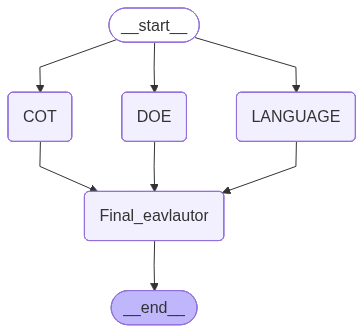

In [90]:
graph=StateGraph(UPSC)

graph.add_node('DOE',DOE)
graph.add_node('COT',COT)
graph.add_node('LANGUAGE',language)
graph.add_node('Final_eavlautor',Final_eavlautor)

graph.add_edge(START,'DOE')
graph.add_edge(START,'COT')
graph.add_edge(START,'LANGUAGE')
graph.add_edge('DOE','Final_eavlautor')
graph.add_edge('COT','Final_eavlautor')
graph.add_edge('LANGUAGE','Final_eavlautor')
graph.add_edge('Final_eavlautor',END)
workflow=graph.compile()
workflow

In [91]:
essay="""

Artificial intelligence is the simulation of human intelligence by computers and machines, enabling them to learn, reason, adapt and solve problems independently. Since its origins in the 1950s, AI has grown from a theoretical concept into one of the most powerful and far-reaching technologies in the world today. 

In our daily lives, artificial intelligence is more present than most people realise. From the moment we unlock our phones using facial recognition to the personalised content we see on social media, AI is quietly shaping our experiences and decisions. Virtual assistants, smart navigation systems and AI-powered customer service tools have become so commonplace that we often take them for granted. 

The influence of artificial intelligence extends far beyond personal convenience. In healthcare, AI is revolutionising the way diseases are diagnosed and treated, enabling doctors to detect conditions earlier and more accurately. In education, intelligent learning platforms are personalising the student experience, helping learners progress at their own pace. In transport, self-driving vehicles are inching closer to becoming a mainstream reality. 

However, the rapid advancement of artificial intelligence raises serious ethical questions. The potential for job displacement, the misuse of personal data and the risk of algorithmic bias are all concerns that must be addressed thoughtfully and urgently. Ensuring that AI is developed transparently and regulated fairly is essential to prevent harm and promote trust. 

Artificial intelligence holds immense promise for humanity’s future. With the right safeguards in place, it can solve some of the world’s most pressing problems and improve the quality of life for people everywhere. 


"""
respose=workflow.invoke({'Essay':essay})

In [92]:
respose

{'language_feedback': "The essay is well-structured with clear examples of AI's impact across various sectors. The language is precise and appropriate, though some phrases could be more original (e.g., 'quietly shaping our experiences' is slightly overused). The ethical concerns section is balanced but could explore potential solutions in greater depth. Minor grammatical improvements (e.g., 'Evalauate' typo in the prompt) and stronger concluding statements would enhance the overall quality.",
 'depth_feedback': "The essay provides a clear overview of artificial intelligence (AI), its applications in daily life, and its broader societal impacts. It demonstrates a good understanding of AI's role across various sectors like healthcare, education, and transportation, while also addressing ethical concerns. However, the depth of analysis could be improved by incorporating more specific examples (e.g., case studies of AI in healthcare), discussing technical challenges (e.g., limitations of c